In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv(r"C:\Users\HP\Downloads\StudentsPerformance (1).csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


PART A : Vector & Matrix Fundamentals

In [73]:
A = np.array([
    df.loc[0, 'math score'],
    df.loc[0, 'reading score'],
    df.loc[0, 'writing score']
])

print(A)

[72 72 74]


In [74]:
# Norm-1

norm1 = np.linalg.norm(A, 1)

print("Norm-1 =", norm1)

Norm-1 = 218.0


In [75]:
# Norm-2

norm2 = np.linalg.norm(A, 2)

print("Norm-2 =", norm2)

Norm-2 = 125.8729518204765


In [76]:
B = np.array([
    df.loc[1, 'math score'],
    df.loc[1, 'reading score'],
    df.loc[1, 'writing score']
])

In [77]:
# DOT Product

dot_product = np.dot(A, B)
print(dot_product)

17960


In [78]:
angle = np.arccos(dot_product / (np.linalg.norm(A) * np.linalg.norm(B)))
print(angle)

0.10957379215422439


In [79]:
# Find cross product A×B

cross_product = np.cross(A, B)
print(cross_product)

[ -324 -1230  1512]


In [80]:
projection = (np.dot(A, B) / np.dot(B, B)) * B
print(projection)

[60.14268381 78.44697889 76.70371269]


PART B : Matrix Operations

In [81]:
matrix = df[['math score', 'reading score', 'writing score']].head(5)
M = matrix.values
print(M)

[[72 72 74]
 [69 90 88]
 [90 95 93]
 [47 57 44]
 [76 78 75]]


In [82]:
# ADDITION

addition = M + M
print(addition)

[[144 144 148]
 [138 180 176]
 [180 190 186]
 [ 94 114  88]
 [152 156 150]]


In [83]:
# MULTIPICATION

multiplication = np.dot(M, M.T)
print(multiplication)

[[15844 17960 20202 10744 16638]
 [17960 20605 22944 12245 18864]
 [20202 22944 25774 13737 21225]
 [10744 12245 13737  7394 11318]
 [16638 18864 21225 11318 17485]]


In [84]:
# Transpose
transpose = M.T
print(transpose)


[[72 69 90 47 76]
 [72 90 95 57 78]
 [74 88 93 44 75]]


In [85]:
# inverse
square_matrix = M[:3, :3]
inverse = np.linalg.inv(square_matrix)
print(inverse)

[[-0.00185391 -0.06192065  0.06006674]
 [-0.27864294 -0.00667408  0.22803115]
 [ 0.28642937  0.06674082 -0.28031146]]


In [98]:
# Determinant
determinant = np.linalg.det(square_matrix)
print(determinant)

-5393.999999999986


PART C : Linear Transformations & Geometry

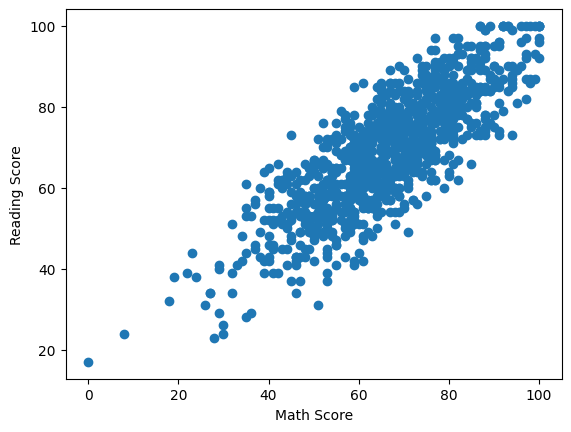

In [ ]:
#  2D

plt.scatter(df['math score'],df['reading score'])
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.show()

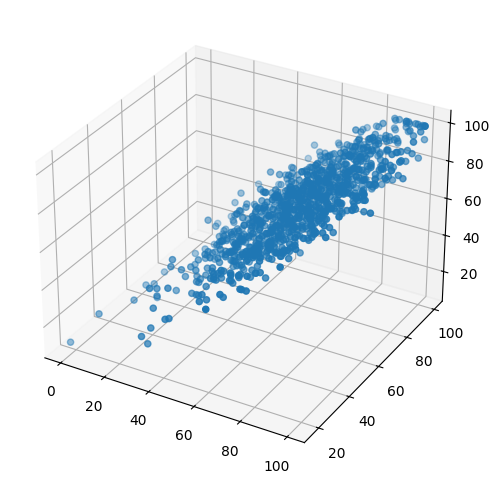

In [88]:
# 3D Plane

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['math score'],df['reading score'],df['writing score'])
plt.show()

PART D : Eigenvalues & Decomposition

In [89]:
# Covariance Matrix

data = df[['math score', 'reading score', 'writing score']]
cov_matrix = np.cov(data.T)
print(cov_matrix)

[[229.918998   180.99895796 184.93913313]
 [180.99895796 213.1656046  211.78666066]
 [184.93913313 211.78666066 230.90799199]]


In [90]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print(eigenvalues)
print(eigenvectors)

[610.12126748  53.91836027   9.95296685]
[[ 0.56264911  0.82561176  0.04232262]
 [ 0.57397682 -0.35329218 -0.73873896]
 [ 0.59495932 -0.43994302  0.67266154]]


In [91]:
# LU decomposition

from scipy.linalg import lu

matrix = df[['math score', 'reading score', 'writing score']].head(3).values

P, L, U = lu(matrix)
print(P)
print(L)
print(U)

[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
[[ 1.          0.          0.        ]
 [ 0.76666667  1.          0.        ]
 [ 0.8        -0.23300971  1.        ]]
[[90.         95.         93.        ]
 [ 0.         17.16666667 16.7       ]
 [ 0.          0.          3.49126214]]


In [92]:
# Singular Value Decomposition (SVD)

U, S, VT = np.linalg.svd(data)
print(U)
print(S)
print(VT)

[[-0.03317199 -0.00541785  0.02205361 ... -0.02426754 -0.03092321
  -0.03573731]
 [-0.03766067  0.05929734 -0.01420352 ... -0.03497012 -0.02765949
  -0.02345128]
 [-0.04231713  0.00180153 -0.00501817 ... -0.03248147  0.0021719
   0.00924432]
 ...
 [-0.02971126  0.02214602 -0.03871462 ...  0.99727079 -0.0015768
  -0.00133824]
 [-0.03396814  0.02364642 -0.00293614 ... -0.00148955  0.99836938
  -0.00169514]
 [-0.03792127  0.02096931  0.00532127 ... -0.00122038 -0.00167113
   0.99817449]]
[3793.77091192  232.09008337  101.03692915]
[[-0.56292211 -0.58853    -0.58030262]
 [-0.82472596  0.35386659  0.44114117]
 [ 0.0542751  -0.72691876  0.6845753 ]]


PART E : Dimensionality Reduction

[[  8.48837536   1.26411978]
 [ 25.46144129 -13.73117695]
 [ 43.12175323  -0.35950596]
 [-32.0362842   -0.87850104]
 [ 14.77779203   2.00687073]]


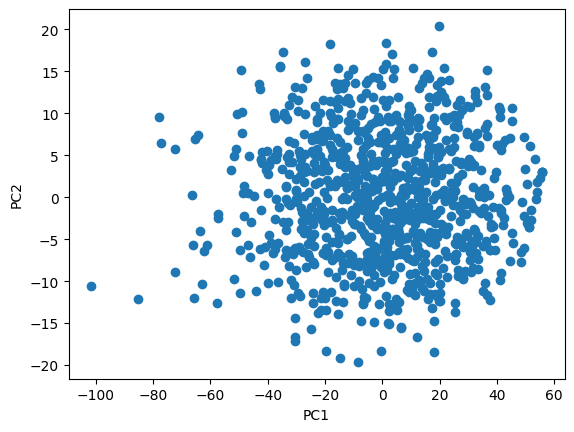

In [93]:
# PCA

from sklearn.decomposition import PCA

X = df[['math score', 'reading score', 'writing score']]
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)
print(principal_components[:5])
plt.scatter(principal_components[:,0],principal_components[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [94]:
df['average'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

In [95]:
df['category'] = np.where(df['average'] >= 70,'Above Average','Below Average')

In [96]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['category'])

[[-0.51697982]
 [-1.75974752]
 [-2.89256546]
 [ 1.96268615]
 [-1.00693908]]


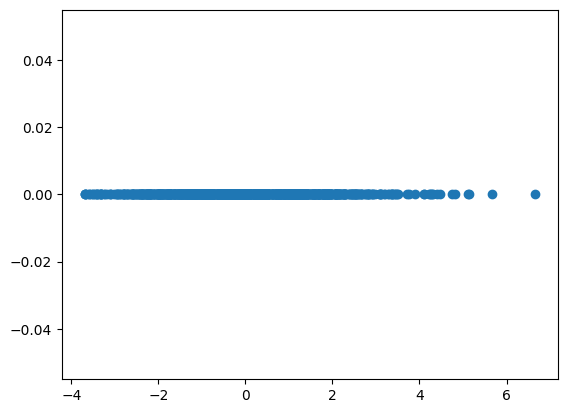

In [97]:
# LDA

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X = df[['math score', 'reading score', 'writing score']]
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)
print(X_lda[:5])

plt.scatter(X_lda,np.zeros_like(X_lda))
plt.show()